# OLMo-2-1B × opc-sft-stage2 leaderboard — long-horizon (r=64, 9000 steps, ~225M tokens)

Long-horizon characterization from `docs/notes/polar_product/tight_chord_paper_plan.md` (Phase L). Cell: OLMo-2-1B × `opc-sft-stage2` (4 sub-configs concat, 436k docs → 150k packed slots @ seq=2048) × r=64 × global_batch=16 (batch=4 × accum=4) × packed_v1 × constant LR × α=r × all-linear × bf16 × compile × single-GPU Blackwell. `max_steps=9000` ≈ 225M unique content tokens (~295M slot-tokens at 75% fill).

Source label: **OLMo OPC eval JSONL logs**: `allenai/OLMo-2-0425-1B`; `data/opc_sft_stage2_all_packed_seq2048`; `packed_v1` / `packed_v1.1`; seq2048; 9k-step eval logs.

Diagnostic q_agree source: **OLMo OPC JSONL q_agree**: `optim_step.awc_q_agree_*` from `logs/chord_tight_slack_phase_L_1b_r256_lr2_blackwell` (r256, ns=5, lr={3e-3,1e-2}). These are JSONL diagnostics, not snapshot-registry rows.

Phase L LR sweep, seed=0, three optimizer arms. AdamW + chord-tight each pool three sub-sweeps (original L1, packed-v1.1 repack of same η values, η-extension); chord-tight-clean κ_sr=0.75 is a single sub-sweep added 2026-05-26 to test whether the packed_v1 Magicoder winner transfers.

- **AdamW**: η ∈ {3e-5, 1e-4, 3e-4, 1e-3, 3e-3}
- **chord-tight (polar, k=1)** (`adam-polar-product-lora-coupled-spectral-chord-tight`): η ∈ {3e-3, 1e-2, 3e-2, 1e-1, 3e-1}
- **chord-tight-clean κ_sr=0.75** (`adam-polar-product-lora-coupled-spectral-chord-tight-clean`, polar_method=ssc, ssc_kappa_solver=stable_rank, picard=2): η ∈ {1e-3, 3e-3, 1e-2, 3e-2, 1e-1}

Source log groups: `{adamw,chord_tight}_phase_L_lrsweep_r64_{blackwell,repack_blackwell,extension_blackwell}`, `chord_tight_clean_ssc_kappa075_phase_L_lrsweep_r64_blackwell`.


In [8]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.loader import load_runs
from lora_playground.plotting import compare_variants_figure

# Plain chord-tight k=2 (ns + polar_express) removed from the leaderboard:
# the 2/(ρ·s) cross-coupling coefficient (optim.py:5573) does not benefit
# from picard>1 (packed_v1 r=64 matched-isolation: k=1 0.5120 vs k=3
# 0.5122). Replaced by chord-tight-clean k=2 (1/η coupling, optim.py:5057)
# which on packed_v1 r=64 ns improves k=1 0.5110 → k=3 0.5072.
GROUPS = [
    'adamw_phase_L_lrsweep_r64_blackwell',
    'chord_tight_phase_L_lrsweep_r64_blackwell',
    'adamw_phase_L_lrsweep_r64_repack_blackwell',
    'chord_tight_phase_L_lrsweep_r64_repack_blackwell',
    'adamw_phase_L_lrsweep_r64_extension_blackwell',
    'chord_tight_phase_L_lrsweep_r64_extension_blackwell',
    'chord_tight_clean_ssc_kappa075_phase_L_lrsweep_r64_blackwell',  # κ_sr=0.75 robustness check (k=2)
    'chord_tight_clean_ssc_fixedc_c0p2_phase_L_lrsweep_r64_gpuxl_h200',  # fixed-c=0.2 comparator k=2 (on H200)
    'chord_tight_polar_express_phase_L_lrsweep_r64_gpuxl_h200',  # chord-tight k=1 polar_express @ 10 iters (legacy H200 — walltimed at step 750)
    'chord_tight_polar_express_phase_L_lrsweep_r64_gpuxl_h200_resub',  # chord-tight k=1 polar_express @ 10 iters (H200 resub — completed to step 9000)
    'chord_tight_polar_express_phase_L_lrsweep_r64_lr1e-3_blackwell',  # low-η tail extension (lr=1e-3) for k=1 polar_express — Blackwell (gpuxl 4-GPU-min blocked H200)
    'chord_tight_clean_ssc_kappa075_phase_L_lrsweep_r64_extension_blackwell',  # κ_sr=0.75 LR extension to {3e-1, 1e0}
    'chord_tight_clean_ns_phase_L_lrsweep_r64_k2_blackwell',                # chord-tight-clean k=2 ns (1/η coupling, picard=2)
    'chord_tight_clean_polar_express_phase_L_lrsweep_r64_k2_gpuxl_h200',    # chord-tight-clean k=2 polar_express (1/η coupling, picard=2) — on H200 (matches predecessor 6450610)
    'chord_tight_clean_ssc_kappa075_k1_phase_L_lrsweep_r64_blackwell',      # κ_sr=0.75 k=1 ablation (at k=1 cross-coupling = 0 → polar+SSC)
    'chord_tight_clean_ssc_fixedc_c0p2_k1_phase_L_lrsweep_r64_blackwell',   # c=0.2 k=1 ablation (at k=1 cross-coupling = 0 → polar+SSC)
]

runs = load_runs(where={'log_group': GROUPS},
                 logs_root='../logs', warn_cross_commit=False)

# Dedup: keep the longest-trajectory run per (optimizer, lr, ssc_kappa).
# Phase-L extension runs were resumed from checkpoints, producing two cfg
# events per cell that differ in `resume_from`/`checkpoint_dir`. The loader
# treats them as distinct series; for the leaderboard we want the single
# continuation that reaches the highest step. Adding ssc_kappa to the key
# keeps room for future κ values without collapsing them onto each other.
_dedup = {}
for cfg, evs in runs:
    key = (cfg['optimizer'], float(cfg['lr']), cfg.get('ssc_kappa'), cfg.get('ssc_c'), cfg.get('polar_method'), cfg.get('_derived', {}).get('effective_picard_iters', cfg.get('picard_iters_override')))
    last_step = evs[-1]['step'] if evs else -1
    prev = _dedup.get(key)
    if prev is None or last_step > prev[1]:
        _dedup[key] = ((cfg, evs), last_step)
runs = [v[0] for v in _dedup.values()]

print(f'loaded: {len(runs)} runs (after dedup)')
for cfg, evs in sorted(runs, key=lambda r: (r[0]['optimizer'], r[0].get('ssc_kappa') or 0, float(r[0]['lr']))):
    last = evs[-1]
    kappa_tag = f"κ={cfg['ssc_kappa']}" if cfg.get('ssc_kappa') is not None else ''
    eff_k = cfg.get('_derived', {}).get('effective_picard_iters', cfg.get('picard_iters_override'))
    k_tag = f"k={eff_k}" if eff_k is not None else ''
    print(f"  {cfg['optimizer']:55s} {kappa_tag:9s} {k_tag:4s} η={float(cfg['lr']):.0e}  "
          f"step={last['step']}  eval={last['eval_loss']:.4f}  "
          f"[{cfg.get('log_group', '?')}]")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  [loader] excluded 156 run(s): 11 for 'Superseded by later chord-tight runs at the same cfg; +0.01 above seed cluster. See log_00 entry.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_01.out, r64_chord_postfix_validation_4k_blackwell/log_02.out, r64_chord_postfix_validation_4k_blackwell/log_03.out, +8 more); 1 for 'Superseded by later chord-tight runs at the same cfg; runs systematically +0.01 above seed cluster from descendants of ef6b3bc. Legacy registry entry blanket-excluded commit 91122ce; we narrow to the affected group since the bug surface was specific to this validation sweep.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_00.out); 7 for 'buggy ε_rel (contam rerun cleanup, pre-λ_max-fix)' (e.g. eps_rel_lr_tuned_4k_blackwell/log_00.out, eps_rel_lr_tuned_4k_blackwell/log_01.out, eps_rel_lr_tuned_4k_blackwell/log_02.out, +4 more); 8 for 'buggy ε_rel (precond_delta_relative fix app

## r=64 — k=1 family


,AdamW,"chord-tight k=1 (ns, polar)",chord-tight k=1 polar_express,chord-tight-clean κ_sr=0.75 k=1,chord-tight-clean c=0.2 k=1
lr,,,,,
0.000030,0.8071,—,—,—,—
0.000100,0.7721,—,—,—,—
0.000300,0.7702,—,—,—,—
0.001000,0.8953,—,0.7910,0.7944,0.7987
0.003000,1.7074,0.7787,0.7653,0.7695,0.7710
0.010000,—,0.7594,0.7574,0.7569,0.7574
0.030000,—,0.7547,0.7775,0.7648,0.7683
0.100000,—,0.7631,0.8508,0.7956,0.8064
0.300000,—,0.7785,0.9668,—,—


,variant,best_lr,final,delta,delta_sigma
0,AdamW,3e-04,0.7702,—,—
1,"chord-tight k=1 (ns, polar)",3e-02,0.7547,-0.0155,-9.09σ
2,chord-tight k=1 polar_express,1e-02,0.7574,-0.0128,-7.54σ
3,chord-tight-clean κ_sr=0.75 k=1,1e-02,0.7569,-0.0133,-7.81σ
4,chord-tight-clean c=0.2 k=1,1e-02,0.7574,-0.0128,-7.53σ


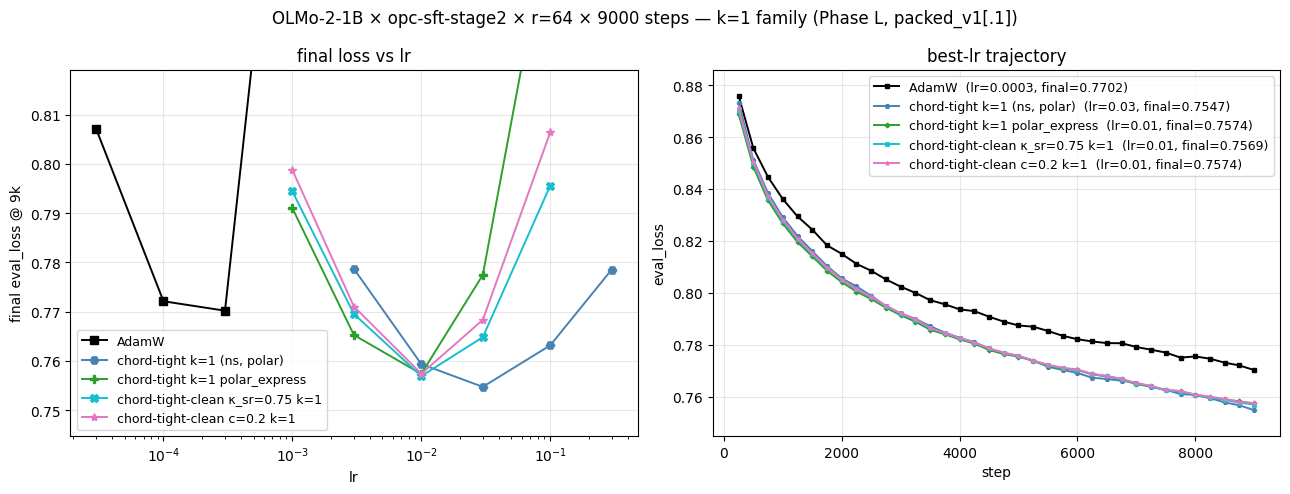

(            AdamW  chord-tight k=1 (ns, polar)  chord-tight k=1 polar_express  \
 lr                                                                              
 0.00003  0.807118                          NaN                            NaN   
 0.00010  0.772106                          NaN                            NaN   
 0.00030  0.770190                          NaN                            NaN   
 0.00100  0.895279                          NaN                       0.790987   
 0.00300  1.707379                     0.778677                       0.765254   
 0.01000       NaN                     0.759352                       0.757365   
 0.03000       NaN                     0.754735                       0.777453   
 0.10000       NaN                     0.763150                       0.850767   
 0.30000       NaN                     0.778536                       0.966757   
 
          chord-tight-clean κ_sr=0.75 k=1  chord-tight-clean c=0.2 k=1  
 lr                    

In [9]:
OPT_CT       = 'adam-polar-product-lora-coupled-spectral-chord-tight'
OPT_CT_CLEAN = 'adam-polar-product-lora-coupled-spectral-chord-tight-clean'

def variant_key(cfg):
    opt = cfg.get('optimizer')
    if opt == 'adamw':
        return 'AdamW'
    eff_k = cfg.get('_derived', {}).get('effective_picard_iters', cfg.get('picard_iters_override'))
    pm = cfg.get('polar_method')
    # Polar pre-norm regime tag — distinguishes pre-fix chord-tight-clean
    # ns/polar_express runs (redundant Frob pre-norm, whitening_fraction ≈ 0.72)
    # from post-fix (pre_norm='none', faithful polar). For chord-tight (no §2.5)
    # it is always 'frob' by design, so the suffix only fires for clean runs.
    pre_norm = cfg.get('_derived', {}).get('effective_polar_pre_norm')
    ctc_polar_suffix = ''
    if opt == OPT_CT_CLEAN and pm in ('ns', 'polar_express') and pre_norm == 'none':
        ctc_polar_suffix = ' [post-fix]'
    # Plain chord-tight (2/(ρ·s) coupling): k=1 only — k=2 dropped because the
    # coefficient does not benefit from picard>1. The ε_rel relative-damping
    # probe (precond_delta_relative=True) is split into its own cell below, so
    # it must NOT be loaded into the groups feeding this variant_key.
    if opt == OPT_CT and pm == 'polar_express' and eff_k == 1:
        return 'chord-tight k=1 polar_express'
    if opt == OPT_CT and eff_k == 1:
        return 'chord-tight k=1 (ns, polar)'
    # chord-tight-clean SSC arms: split by picard (k=1 ablation vs k=2). At k=1
    # the anchored-FW cross-coupling correction is identically zero, so k=1 SSC
    # = polar + SSC clip (Lemma 4 / §A2 of algorithm_ssc_kappa.md).
    if opt == OPT_CT_CLEAN and cfg.get('ssc_kappa') == 0.75:
        return f'chord-tight-clean κ_sr=0.75 k={eff_k}'
    if opt == OPT_CT_CLEAN and cfg.get('ssc_c') == 0.2:
        return f'chord-tight-clean c=0.2 k={eff_k}'
    if (opt == OPT_CT_CLEAN and eff_k == 2
            and cfg.get('ssc_kappa') is None and cfg.get('ssc_c') is None):
        if pm == 'polar_express':
            return f'chord-tight-clean k=2 polar_express{ctc_polar_suffix}'
        return f'chord-tight-clean k=2 (ns){ctc_polar_suffix}'
    return None

# Canonical colors/markers (AdamW gets the reserved black overlay).
from lora_playground.plotting.colors import OPTIM_COLORS, OPTIM_MARKERS
VARIANT_COLORS = {
    'AdamW':                                  OPTIM_COLORS['adamw'],
    'chord-tight k=1 (ns, polar)':            '#4682b4',  # steelblue
    'chord-tight k=1 polar_express':          '#2ca02c',  # green
    'chord-tight-clean κ_sr=0.75 k=2':        OPTIM_COLORS[OPT_CT_CLEAN],  # dark brown
    'chord-tight-clean κ_sr=0.75 k=1':        '#17becf',  # bright cyan — k=1 ablation
    'chord-tight-clean c=0.2 k=2':            '#ff7f0e',  # vivid orange
    'chord-tight-clean c=0.2 k=1':            '#e377c2',  # hot pink — k=1 ablation
    'chord-tight-clean k=2 (ns)':             '#d62728',  # red
    'chord-tight-clean k=2 polar_express':    '#9467bd',  # purple
}
VARIANT_MARKERS = {
    'AdamW':                                  OPTIM_MARKERS.get('adamw', 's'),
    'chord-tight k=1 (ns, polar)':            OPTIM_MARKERS.get(OPT_CT, 'o'),
    'chord-tight k=1 polar_express':          'P',
    'chord-tight-clean κ_sr=0.75 k=2':        OPTIM_MARKERS.get(OPT_CT_CLEAN, '^'),
    'chord-tight-clean κ_sr=0.75 k=1':        'X',
    'chord-tight-clean c=0.2 k=2':            'D',
    'chord-tight-clean c=0.2 k=1':            '*',
    'chord-tight-clean k=2 (ns)':             'o',
    'chord-tight-clean k=2 polar_express':    'P',
}

# Variant groupings — split the crowded panel into k=1 / k=2 families so each
# figure stays legible (the ε_rel probe lives in its own cell further down).
K1_VARIANTS = [
    'chord-tight k=1 (ns, polar)',
    'chord-tight k=1 polar_express',
    'chord-tight-clean κ_sr=0.75 k=1',
    'chord-tight-clean c=0.2 k=1',
]
K2_VARIANTS = [
    'chord-tight-clean k=2 (ns)',
    'chord-tight-clean k=2 polar_express',
    'chord-tight-clean κ_sr=0.75 k=2',
    'chord-tight-clean c=0.2 k=2',
]

from IPython.display import display

def render_panel(prefetched, variant_labels, suptitle, *, ref_label='AdamW'):
    """One compare-variants panel for a subset of variants (AdamW always the
    reference overlay). auto_ylim (library default) clips diverged runs."""
    variants = {'AdamW': {}}
    variants.update({v: {} for v in variant_labels})
    fig, tdf, sdf = compare_variants_figure(
        variants=variants, common_where={}, ref_label=ref_label,
        sigma_ref=0.0017, suptitle=suptitle, figsize=(13, 5),
        max_steps=9000, allow_partial=True,
        prefetched_runs=prefetched, variant_key=variant_key,
        colors=VARIANT_COLORS, markers=VARIANT_MARKERS,
    )
    display(tdf.style.format('{:.4f}', na_rep='—'))
    display(sdf.style.format({'final': '{:.4f}', 'delta': '{:+.4f}',
                              'delta_sigma': '{:+.2f}σ', 'best_lr': '{:.0e}'},
                             na_rep='—'))
    plt.show()
    return tdf, sdf

render_panel(runs, K1_VARIANTS,
             'OLMo-2-1B × opc-sft-stage2 × r=64 × 9000 steps — k=1 family (Phase L, packed_v1[.1])')


## r=64 — k=2 (picard) family


,AdamW,chord-tight-clean k=2 (ns),chord-tight-clean k=2 polar_express,chord-tight-clean κ_sr=0.75 k=2,chord-tight-clean c=0.2 k=2
lr,,,,,
0.000030,0.8071,—,—,—,—
0.000100,0.7721,—,—,—,—
0.000300,0.7702,—,—,—,—
0.001000,0.8953,—,—,0.8165,0.8167
0.003000,1.7074,0.7981,0.7870,0.7936,0.7929
0.010000,—,0.7785,0.7646,0.7742,0.7728
0.030000,—,0.7666,0.7571,0.7623,0.7620
0.100000,—,0.7631,0.7709,0.7571,0.7575
0.300000,—,0.7673,0.8155,0.7627,—


,variant,best_lr,final,delta,delta_sigma
0,AdamW,3e-04,0.7702,—,—
1,chord-tight-clean k=2 (ns),1e-01,0.7631,-0.0071,-4.18σ
2,chord-tight-clean k=2 polar_express,3e-02,0.7571,-0.0131,-7.70σ
3,chord-tight-clean κ_sr=0.75 k=2,1e-01,0.7571,-0.0131,-7.69σ
4,chord-tight-clean c=0.2 k=2,1e-01,0.7575,-0.0127,-7.44σ


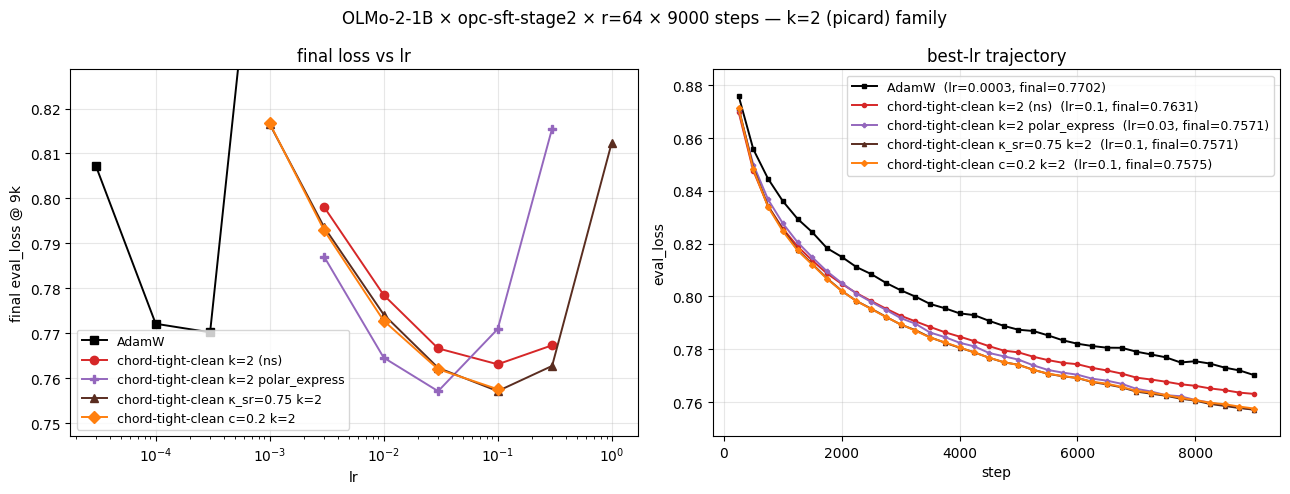

(            AdamW  chord-tight-clean k=2 (ns)  \
 lr                                              
 0.00003  0.807118                         NaN   
 0.00010  0.772106                         NaN   
 0.00030  0.770190                         NaN   
 0.00100  0.895279                         NaN   
 0.00300  1.707379                    0.798084   
 0.01000       NaN                    0.778497   
 0.03000       NaN                    0.766623   
 0.10000       NaN                    0.763085   
 0.30000       NaN                    0.767312   
 1.00000       NaN                         NaN   
 
          chord-tight-clean k=2 polar_express  chord-tight-clean κ_sr=0.75 k=2  \
 lr                                                                              
 0.00003                                  NaN                              NaN   
 0.00010                                  NaN                              NaN   
 0.00030                                  NaN                         

In [10]:
render_panel(runs, K2_VARIANTS,
             'OLMo-2-1B × opc-sft-stage2 × r=64 × 9000 steps — k=2 (picard) family')


## r=256 — k=1 family (rank-extension robustness)


In [11]:
GROUPS_R256 = [
    'adamw_phase_L_lrsweep_r256_blackwell',
    'chord_tight_phase_L_lrsweep_r256_blackwell',
    'chord_tight_clean_ssc_kappa075_phase_L_lrsweep_r256_blackwell',
    'chord_tight_clean_ssc_fixedc_c0p2_phase_L_lrsweep_r256_gpuxl_h200',  # fixed-c=0.2 comparator k=2 (on H200)
    'chord_tight_polar_express_phase_L_lrsweep_r256_gpuxl_h200',  # chord-tight k=1 polar_express @ 10 iters (legacy H200 slow run)
    'chord_tight_polar_express_phase_L_lrsweep_r256_blackwell',  # chord-tight k=1 polar_express batched-Gram (Blackwell)
    'chord_tight_polar_express_phase_L_lrsweep_r256_lr1e-3_blackwell',  # low-η tail extension (lr=1e-3) for k=1 polar_express
    'chord_tight_clean_ssc_kappa075_phase_L_lrsweep_r256_extension_blackwell',  # κ_sr=0.75 LR extension to {3e-1, 1e0}
    'chord_tight_clean_ns_phase_L_lrsweep_r256_k2_blackwell',             # chord-tight-clean k=2 ns (1/η coupling, picard=2)
    'chord_tight_clean_polar_express_phase_L_lrsweep_r256_k2_blackwell',  # chord-tight-clean k=2 polar_express (1/η coupling, picard=2)
    'chord_tight_clean_ssc_kappa075_k1_phase_L_lrsweep_r256_blackwell',   # κ_sr=0.75 k=1 ablation (at k=1 cross-coupling = 0 → polar+SSC)
    'chord_tight_clean_ssc_fixedc_c0p2_k1_phase_L_lrsweep_r256_blackwell', # c=0.2 k=1 ablation (at k=1 cross-coupling = 0 → polar+SSC)
    'chord_tight_phase_L_r256_epsrel_ns_probe_blackwell_v2',  # \u03b5_rel relative-damping NS probe (ns\u2208{5,8}, eps=1e-2)
]

runs_r256 = load_runs(where={'log_group': GROUPS_R256},
                      logs_root='../logs', warn_cross_commit=False)

# Same dedup pattern as r=64: keep longest-trajectory per (optimizer, lr, ssc_kappa).
_dedup = {}
for cfg, evs in runs_r256:
    key = (cfg['optimizer'], float(cfg['lr']), cfg.get('ssc_kappa'), cfg.get('ssc_c'), cfg.get('polar_method'), cfg.get('_derived', {}).get('effective_picard_iters', cfg.get('picard_iters_override')))
    last_step = evs[-1]['step'] if evs else -1
    prev = _dedup.get(key)
    if prev is None or last_step > prev[1]:
        _dedup[key] = ((cfg, evs), last_step)
runs_r256 = [v[0] for v in _dedup.values()]

print(f'loaded: {len(runs_r256)} runs (after dedup)')
for cfg, evs in sorted(runs_r256, key=lambda r: (r[0]['optimizer'], r[0].get('ssc_kappa') or 0, float(r[0]['lr']))):
    last = evs[-1]
    kappa_tag = f"κ={cfg['ssc_kappa']}" if cfg.get('ssc_kappa') is not None else ''
    eff_k = cfg.get('_derived', {}).get('effective_picard_iters', cfg.get('picard_iters_override'))
    k_tag = f"k={eff_k}" if eff_k is not None else ''
    print(f"  {cfg['optimizer']:55s} {kappa_tag:9s} {k_tag:4s} η={float(cfg['lr']):.0e}  "
          f"step={last['step']}  eval={last['eval_loss']:.4f}  "
          f"[{cfg.get('log_group', '?')}]")

  [loader] excluded 156 run(s): 11 for 'Superseded by later chord-tight runs at the same cfg; +0.01 above seed cluster. See log_00 entry.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_01.out, r64_chord_postfix_validation_4k_blackwell/log_02.out, r64_chord_postfix_validation_4k_blackwell/log_03.out, +8 more); 1 for 'Superseded by later chord-tight runs at the same cfg; runs systematically +0.01 above seed cluster from descendants of ef6b3bc. Legacy registry entry blanket-excluded commit 91122ce; we narrow to the affected group since the bug surface was specific to this validation sweep.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_00.out); 7 for 'buggy ε_rel (contam rerun cleanup, pre-λ_max-fix)' (e.g. eps_rel_lr_tuned_4k_blackwell/log_00.out, eps_rel_lr_tuned_4k_blackwell/log_01.out, eps_rel_lr_tuned_4k_blackwell/log_02.out, +4 more); 8 for 'buggy ε_rel (precond_delta_relative fix applied but pre-λ_max-fix (9677abe))' (e.g. chord_tight_k3_eps_rel_1e-2_r16r64_lr_sweep_4k_

,AdamW,"chord-tight k=1 (ns, polar)",chord-tight k=1 polar_express,chord-tight-clean κ_sr=0.75 k=1,chord-tight-clean c=0.2 k=1
lr,,,,,
0.000030,0.7760,—,—,—,—
0.000100,0.7524,—,—,—,—
0.000300,0.7952,—,—,—,—
0.001000,1.1470,—,0.7646,0.7689,0.7835
0.003000,2.6515,0.7637,0.7425,0.7458,0.7539
0.010000,—,0.7439,0.7414,0.7387,0.7391
0.030000,—,0.7415,0.7737,0.7503,0.7412
0.100000,—,0.7559,0.8763,0.7778,0.7534
0.300000,—,0.7538,1.0078,—,—


,variant,best_lr,final,delta,delta_sigma
0,AdamW,1e-04,0.7524,—,—
1,"chord-tight k=1 (ns, polar)",3e-02,0.7415,-0.0110,-6.44σ
2,chord-tight k=1 polar_express,1e-02,0.7414,-0.0111,-6.52σ
3,chord-tight-clean κ_sr=0.75 k=1,1e-02,0.7387,-0.0137,-8.05σ
4,chord-tight-clean c=0.2 k=1,1e-02,0.7391,-0.0133,-7.83σ


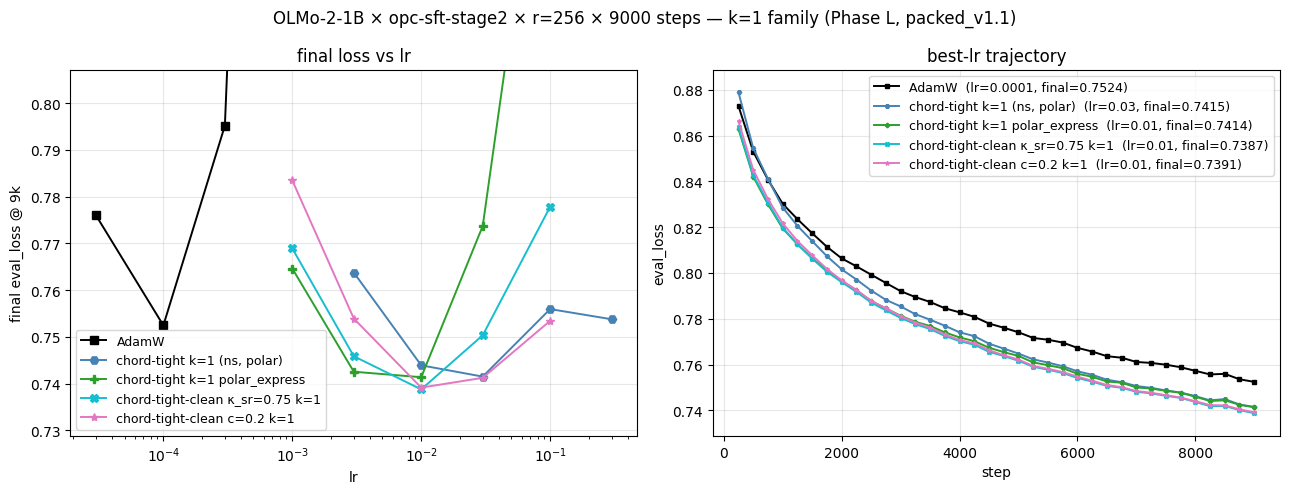

(            AdamW  chord-tight k=1 (ns, polar)  chord-tight k=1 polar_express  \
 lr                                                                              
 0.00003  0.775991                          NaN                            NaN   
 0.00010  0.752439                          NaN                            NaN   
 0.00030  0.795165                          NaN                            NaN   
 0.00100  1.147021                          NaN                       0.764608   
 0.00300  2.651510                     0.763744                       0.742524   
 0.01000       NaN                     0.743895                       0.741352   
 0.03000       NaN                     0.741482                       0.773698   
 0.10000       NaN                     0.755925                       0.876291   
 0.30000       NaN                     0.753751                       1.007795   
 
          chord-tight-clean κ_sr=0.75 k=1  chord-tight-clean c=0.2 k=1  
 lr                    

In [12]:
render_panel(runs_r256, K1_VARIANTS,
             'OLMo-2-1B × opc-sft-stage2 × r=256 × 9000 steps — k=1 family (Phase L, packed_v1.1)')


## r=256 — k=2 (picard) family


,AdamW,chord-tight-clean k=2 (ns),chord-tight-clean k=2 polar_express,chord-tight-clean κ_sr=0.75 k=2,chord-tight-clean c=0.2 k=2
lr,,,,,
0.000030,0.7760,—,—,—,—
0.000100,0.7524,—,—,—,—
0.000300,0.7952,—,—,—,—
0.001000,1.1470,—,—,0.7903,0.7957
0.003000,2.6515,0.7776,0.7697,0.7674,0.7694
0.010000,—,0.7584,0.7509,0.7518,0.7528
0.030000,—,0.7535,0.7439,0.7460,0.7526
0.100000,—,0.7511,0.7422,0.7437,0.7494
0.300000,—,0.7536,0.7680,0.7535,—


,variant,best_lr,final,delta,delta_sigma
0,AdamW,1e-04,0.7524,—,—
1,chord-tight-clean k=2 (ns),1e-01,0.7511,-0.0013,-0.77σ
2,chord-tight-clean k=2 polar_express,1e-01,0.7422,-0.0103,-6.05σ
3,chord-tight-clean κ_sr=0.75 k=2,1e-01,0.7437,-0.0087,-5.14σ
4,chord-tight-clean c=0.2 k=2,1e-01,0.7494,-0.0030,-1.78σ


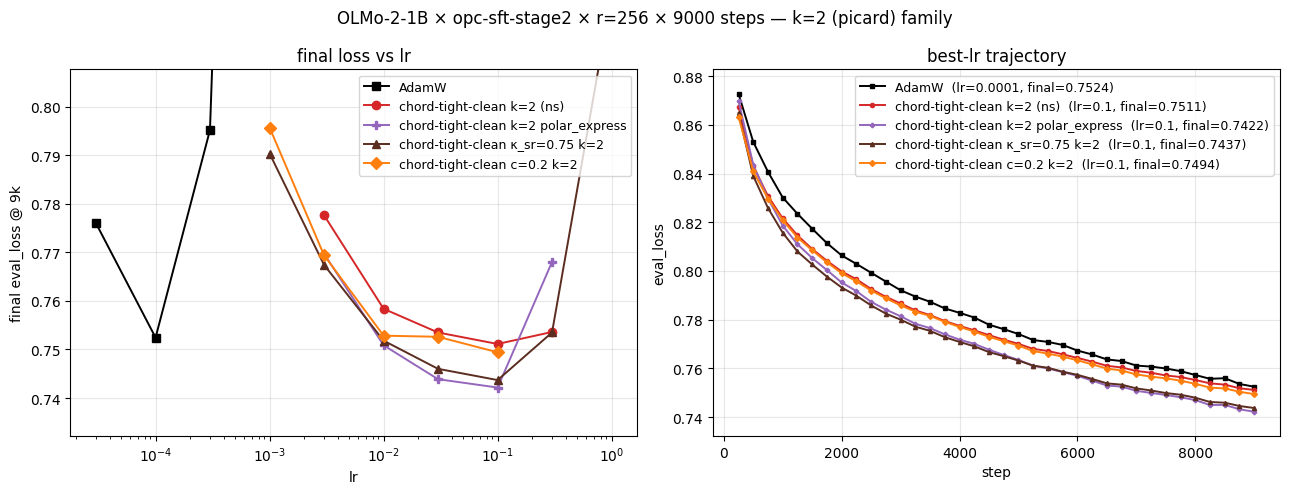

(            AdamW  chord-tight-clean k=2 (ns)  \
 lr                                              
 0.00003  0.775991                         NaN   
 0.00010  0.752439                         NaN   
 0.00030  0.795165                         NaN   
 0.00100  1.147021                         NaN   
 0.00300  2.651510                    0.777649   
 0.01000       NaN                    0.758368   
 0.03000       NaN                    0.753490   
 0.10000       NaN                    0.751126   
 0.30000       NaN                    0.753596   
 1.00000       NaN                         NaN   
 
          chord-tight-clean k=2 polar_express  chord-tight-clean κ_sr=0.75 k=2  \
 lr                                                                              
 0.00003                                  NaN                              NaN   
 0.00010                                  NaN                              NaN   
 0.00030                                  NaN                         

In [13]:
render_panel(runs_r256, K2_VARIANTS,
             'OLMo-2-1B × opc-sft-stage2 × r=256 × 9000 steps — k=2 (picard) family')


## r=256 — ε_rel damping-regime probe


,AdamW,chord-tight abs-damp 1e-6 ns=5,chord-tight ε_rel 1e-2 ns=5,chord-tight ε_rel 1e-2 ns=8,chord-tight polar-express 1e-6 ns=10
lr,,,,,
0.000030,0.7760,—,—,—,—
0.000100,0.7524,—,—,—,—
0.000300,0.7952,—,—,—,—
0.001000,1.1470,—,—,—,—
0.003000,2.6515,0.7670,0.7637,0.7457,0.7425
0.010000,—,0.7453,0.7439,0.7399,0.7414
0.030000,—,0.7388,0.7415,0.7570,0.7737
0.100000,—,0.7424,0.7559,0.8087,0.8763
0.300000,—,0.7538,—,—,1.0078


,variant,best_lr,final,delta,delta_sigma
0,AdamW,1e-04,0.7524,+0.0136,+8.01σ
1,chord-tight abs-damp 1e-6 ns=5,3e-02,0.7388,—,—
2,chord-tight ε_rel 1e-2 ns=5,3e-02,0.7415,+0.0027,+1.57σ
3,chord-tight ε_rel 1e-2 ns=8,1e-02,0.7399,+0.0011,+0.65σ
4,chord-tight polar-express 1e-6 ns=10,1e-02,0.7414,+0.0025,+1.49σ


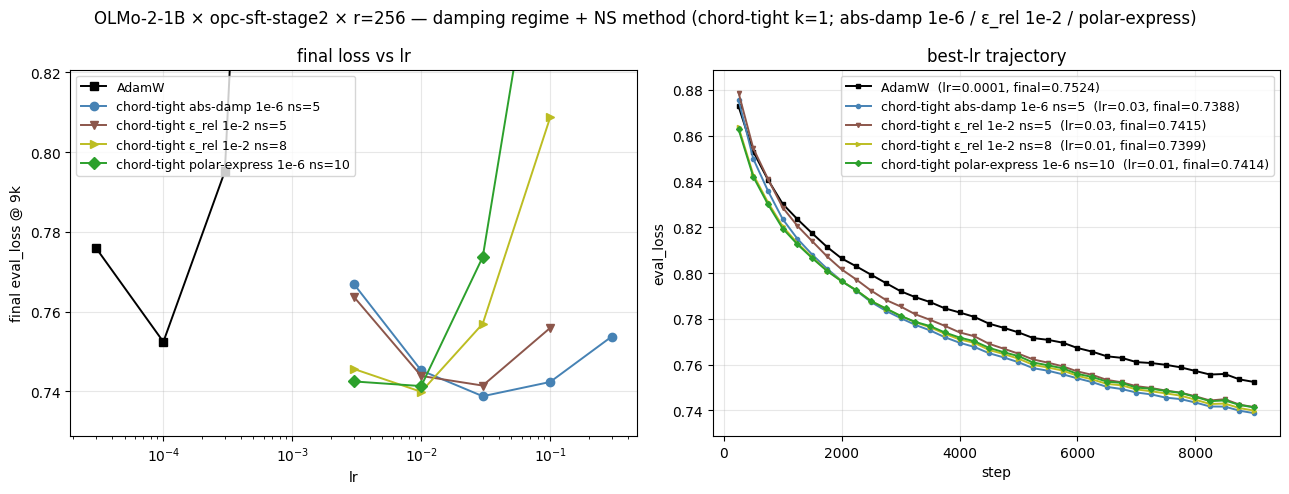

In [14]:
# ── ε_rel damping-regime probe (OLMo OPC r=256) ───────────────────────────
# Does opnorm-RELATIVE preconditioner damping (precond_delta_relative=True,
# eps=1e-2) beat the ABSOLUTE-damping baseline (eps=1e-6), and does relative
# damping make higher-NS (ns=8) polar safer/better? Also overlays the
# polar-express NS method (abs-damp eps=1e-6, ns=10) as a third contrast.
# All arms are chord-tight k=1 (picard=1, plain 2/(ρ·s) coupling); only the
# damping regime + NS method/iteration vary. Δ is vs the abs-damp ns=5 baseline.
EPSREL_GROUPS = [
    'adamw_phase_L_lrsweep_r256_blackwell',                   # reference
    'chord_tight_phase_L_lrsweep_r256_blackwell',             # abs-damp (eps=1e-6) ns=5
    'chord_tight_phase_L_r256_epsrel_ns_probe_blackwell_v2',  # ε_rel (eps=1e-2) ns∈{5,8}
    'chord_tight_polar_express_phase_L_lrsweep_r256_blackwell',  # abs-damp (eps=1e-6) polar-express ns=10, k=1
]
epsrel_runs = load_runs(where={'log_group': EPSREL_GROUPS},
                        logs_root='../logs', warn_cross_commit=False, quiet=True)

def variant_key_epsrel(cfg):
    opt = cfg.get('optimizer')
    if opt == 'adamw':
        return 'AdamW'
    if opt != OPT_CT:
        return None
    ns = cfg.get('muon_ns_steps')
    if cfg.get('polar_method') == 'polar_express':   # abs-damp eps=1e-6, ns=10
        return f'chord-tight polar-express 1e-6 ns={ns}'
    if cfg.get('precond_delta_relative'):            # ε_rel, eps=1e-2
        return f'chord-tight ε_rel 1e-2 ns={ns}'
    if ns == 5:                                      # absolute-damping eps=1e-6 ns=5 baseline
        return 'chord-tight abs-damp 1e-6 ns=5'
    return None

EPSREL_COLORS = {
    'AdamW':                                 OPTIM_COLORS['adamw'],
    'chord-tight abs-damp 1e-6 ns=5':        '#4682b4',  # steelblue
    'chord-tight ε_rel 1e-2 ns=5':           '#8c564b',  # brown
    'chord-tight ε_rel 1e-2 ns=8':           '#bcbd22',  # olive
    'chord-tight polar-express 1e-6 ns=10':  '#2ca02c',  # green
}
EPSREL_MARKERS = {
    'AdamW':                                 OPTIM_MARKERS.get('adamw', 's'),
    'chord-tight abs-damp 1e-6 ns=5':        'o',
    'chord-tight ε_rel 1e-2 ns=5':           'v',
    'chord-tight ε_rel 1e-2 ns=8':           '>',
    'chord-tight polar-express 1e-6 ns=10':  'D',
}

fig, table_df_epsrel, summary_df_epsrel = compare_variants_figure(
    variants={
        'AdamW':                                 {},
        'chord-tight abs-damp 1e-6 ns=5':        {},
        'chord-tight ε_rel 1e-2 ns=5':           {},
        'chord-tight ε_rel 1e-2 ns=8':           {},
        'chord-tight polar-express 1e-6 ns=10':  {},
    },
    common_where={}, ref_label='chord-tight abs-damp 1e-6 ns=5',
    sigma_ref=0.0017,
    suptitle='OLMo-2-1B × opc-sft-stage2 × r=256 — damping regime + NS method (chord-tight k=1; abs-damp 1e-6 / ε_rel 1e-2 / polar-express)',
    figsize=(13, 5), max_steps=9000, allow_partial=True,
    prefetched_runs=epsrel_runs, variant_key=variant_key_epsrel,
    colors=EPSREL_COLORS, markers=EPSREL_MARKERS,
)
display(table_df_epsrel.style.format('{:.4f}', na_rep='—'))
display(summary_df_epsrel.style.format({'final': '{:.4f}', 'delta': '{:+.4f}',
                                        'delta_sigma': '{:+.2f}σ', 'best_lr': '{:.0e}'},
                                       na_rep='—'))
plt.show()
